# Notebook 6 — Chân dung Người Nghỉ việc & Mô hình có thực sự đáng làm?

2 câu hỏi tiếp tục đào sâu:
1. SHAP (Notebooks 4) và phân tích False Negative (notebook 05) đều chỉ ra **một** driver chủ đạo
   (OverTime) và **một** nhóm bị bỏ sót (thâm niên). Nhưng liệu người nghỉ việc có thực sự
   chỉ có 1-2 kiểu, hay có nhiều "chân dung" (persona) khác nhau đang bị gộp chung?
2. Sau tất cả — SMOTE, so sánh 5 mô hình, RandomizedSearchCV, SHAP — **mô hình có thực sự
   tốt hơn một luật đơn giản** kiểu "cứ ai làm thêm giờ thì gọi điện hỏi thăm"? Nếu câu trả
   lời là "không nhiều", đó là một insight quan trọng cần biết trước khi thuyết phục ai đó
   dùng hệ thống này.


In [1]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titleweight'] = 'bold'

df = pd.read_csv("../data/processed/attrition_encoded.csv")
raw = pd.read_csv("../data/raw/WA_Fn-UseC_-HR-Employee-Attrition.csv").drop(
    columns=["EmployeeCount", "StandardHours", "Over18", "EmployeeNumber"])


## 1. Chân dung người nghỉ việc — Phân cụm (K-Means) trên toàn bộ 237 người đã nghỉ

Dùng toàn bộ người đã nghỉ việc trong dataset (không chỉ 47 người ở tập test) để có mẫu đủ
lớn cho phân cụm. Chọn K bằng silhouette score.

In [2]:
leavers = df[df['Attrition']==1].copy()
leavers_raw = raw.iloc[leavers.index].reset_index(drop=True)
leavers = leavers.reset_index(drop=True)
print(f"Số người đã nghỉ việc: {len(leavers)}")

features = ['OverTime_Yes', 'MonthlyIncome', 'Age', 'YearsAtCompany', 'StockOptionLevel',
            'JobSatisfaction', 'EnvironmentSatisfaction', 'JobLevel',
            'BusinessTravel_Travel_Frequently', 'NumCompaniesWorked', 'DistanceFromHome',
            'TotalWorkingYears']
X_cluster = leavers[features].copy()
X_cluster['OverTime_Yes'] = X_cluster['OverTime_Yes'].astype(int)
X_cluster['BusinessTravel_Travel_Frequently'] = X_cluster['BusinessTravel_Travel_Frequently'].astype(int)

scaler_c = StandardScaler()
X_cluster_scaled = scaler_c.fit_transform(X_cluster)

from sklearn.metrics import silhouette_score
sil_scores = {k: silhouette_score(X_cluster_scaled, KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X_cluster_scaled))
              for k in range(2, 7)}
print("Silhouette score theo K:", {k: round(v,3) for k,v in sil_scores.items()})


Số người đã nghỉ việc: 237
Silhouette score theo K: {2: 0.25, 3: 0.147, 4: 0.12, 5: 0.124, 6: 0.131}


> Silhouette cao nhất chỉ 0.25 (ở K=2) — dữ liệu hành vi con người hiếm khi tạo cụm
> tách bạch rõ ràng như dữ liệu kỹ thuật. Đây là phân nhóm **mềm** (soft segmentation),
> mang tính gợi ý xu hướng, không phải ranh giới cứng. Chọn K=4 vì cho ra chân dung dễ diễn
> giải và hành động hơn K=2 (vốn chỉ tách "OT hay không"), dù đánh đổi silhouette thấp hơn.

In [3]:
km = KMeans(n_clusters=4, random_state=42, n_init=10)
labels = km.fit_predict(X_cluster_scaled)
leavers_raw['cluster'] = labels

profile = leavers_raw.groupby('cluster')[['Age','MonthlyIncome','YearsAtCompany','StockOptionLevel',
                                            'NumCompaniesWorked','DistanceFromHome']].mean().round(1)
profile['OverTime_%'] = leavers_raw.groupby('cluster').apply(lambda g: (g['OverTime']=='Yes').mean()*100, include_groups=False).round(0)
profile['BizTravelFreq_%'] = leavers_raw.groupby('cluster').apply(lambda g: (g['BusinessTravel']=='Travel_Frequently').mean()*100, include_groups=False).round(0)
profile['n'] = leavers_raw.groupby('cluster').size()
profile = profile.sort_values('n', ascending=False)
profile


,Age,MonthlyIncome,YearsAtCompany,StockOptionLevel,NumCompaniesWorked,DistanceFromHome,OverTime_%,BizTravelFreq_%,n
cluster,,,,,,,,,
3,28.3,2827.3,2.7,0.4,2.0,9.9,67.0,0.0,90
0,39.2,6325.9,5.6,0.7,4.4,13.4,37.0,16.0,76
1,30.4,3093.2,3.7,0.5,2.3,9.3,59.0,100.0,54
2,46.9,13663.4,20.5,0.6,3.8,6.2,41.0,18.0,17


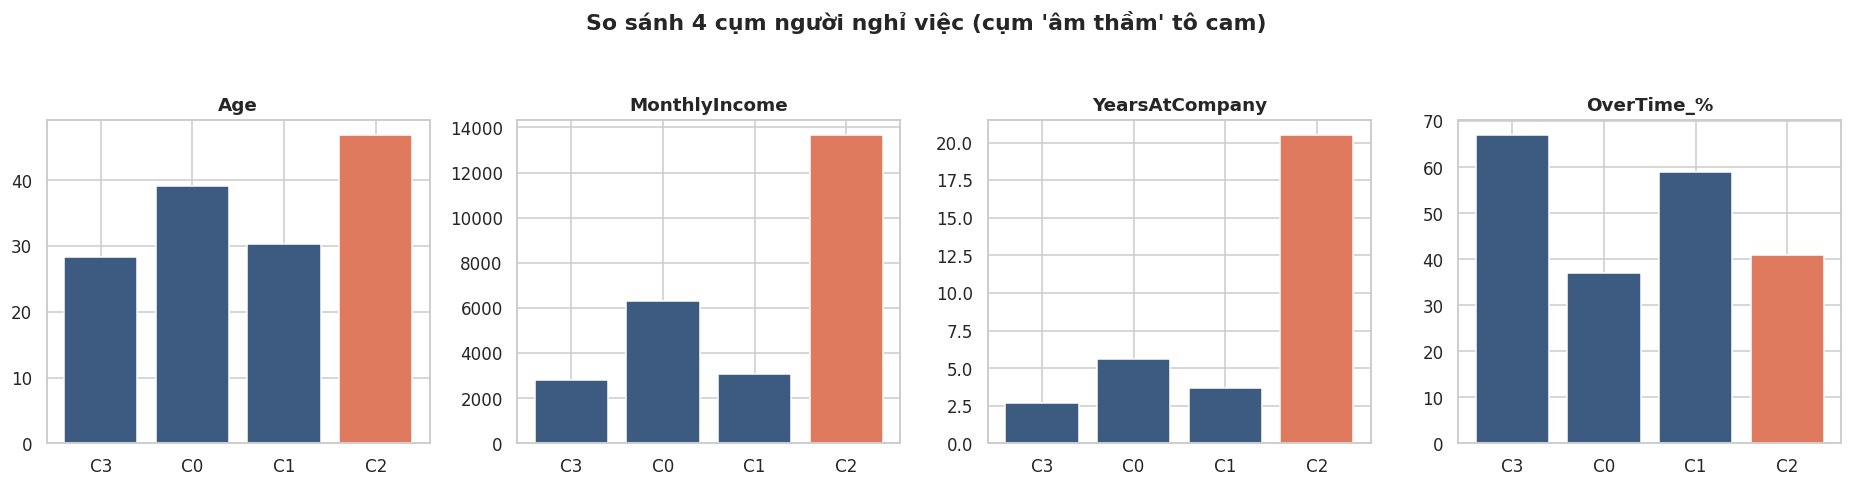


Gán tên cho từng cụm (dựa trên đặc điểm nổi bật nhất):
  Cụm 3 (n=90): 🔥 Nhà nghiên cứu trẻ kiệt sức
  Cụm 0 (n=76): 🧳 Nhân viên hay nhảy việc
  Cụm 1 (n=54): ✈️ Chiến binh công tác
  Cụm 2 (n=17): 🤫 Rời đi trong âm thầm (thâm niên)


In [4]:
persona_names = {
    3: "🔥 Nhà nghiên cứu trẻ kiệt sức",
    0: "🧳 Nhân viên hay nhảy việc",
    1: "✈️ Chiến binh công tác",
    2: "🤫 Rời đi trong âm thầm (thâm niên)",
}

fig, axes = plt.subplots(1, 4, figsize=(17, 4.2))
metrics_to_plot = ['Age', 'MonthlyIncome', 'YearsAtCompany', 'OverTime_%']
for ax, m in zip(axes, metrics_to_plot):
    vals = profile[m]
    colors = ['#e07a5f' if profile.index[i]==2 else '#3d5a80' for i in range(len(profile))]
    ax.bar([f"C{c}" for c in profile.index], vals, color=colors)
    ax.set_title(m)
plt.suptitle("So sánh 4 cụm người nghỉ việc (cụm 'âm thầm' tô cam)", y=1.05, fontweight='bold')
plt.tight_layout()
plt.savefig("../images/18_persona_comparison.png", bbox_inches='tight')
plt.show()

print("\nGán tên cho từng cụm (dựa trên đặc điểm nổi bật nhất):")
for c in profile.index:
    print(f"  Cụm {c} (n={profile.loc[c,'n']:.0f}): {persona_names[c]}")


/tmp/ipykernel_482/1755059663.py:14: UserWarning: Glyph 129523 (\N{LUGGAGE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_482/1755059663.py:14: UserWarning: Glyph 129323 (\N{FACE WITH FINGER COVERING CLOSED LIPS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_482/1755059663.py:14: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_482/1755059663.py:15: UserWarning: Glyph 129523 (\N{LUGGAGE}) missing from font(s) DejaVu Sans.
  plt.savefig("../images/19_persona_pca.png", bbox_inches='tight')
/tmp/ipykernel_482/1755059663.py:15: UserWarning: Glyph 129323 (\N{FACE WITH FINGER COVERING CLOSED LIPS}) missing from font(s) DejaVu Sans.
  plt.savefig("../images/19_persona_pca.png", bbox_inches='tight')
/tmp/ipykernel_482/1755059663.py:15: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  plt.savefig("../images/19_persona_pca.png", bbox_inches='tight')


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 129523 (\N{LUGGAGE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 129323 (\N{FACE WITH FINGER COVERING CLOSED LIPS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


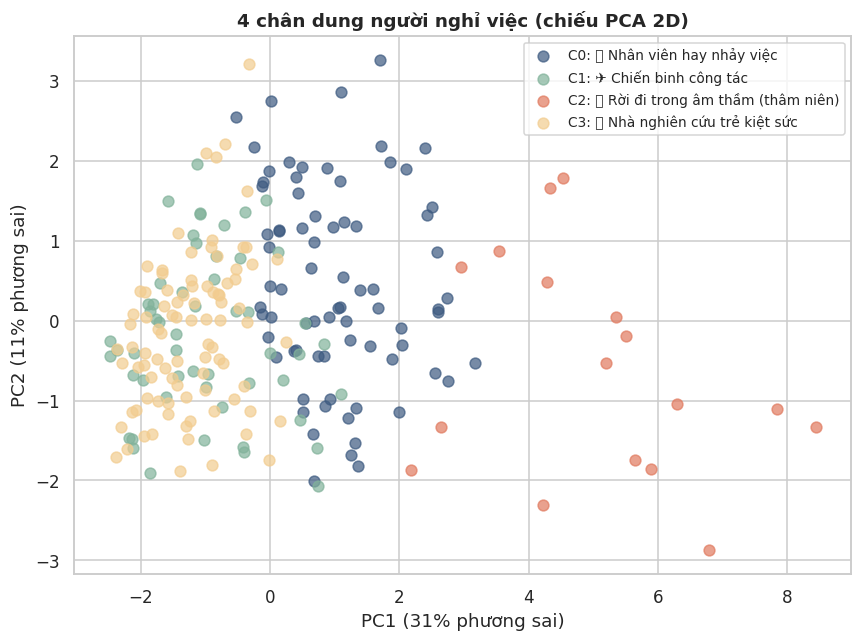

In [5]:
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_cluster_scaled)

plt.figure(figsize=(8, 6))
palette = {0: '#3d5a80', 1: '#81b29a', 2: '#e07a5f', 3: '#f2cc8f'}
for c in sorted(set(labels)):
    mask = labels == c
    plt.scatter(coords[mask, 0], coords[mask, 1], label=f"C{c}: {persona_names[c]}",
                color=palette[c], alpha=0.7, s=50)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.0f}% phương sai)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.0f}% phương sai)")
plt.title("4 chân dung người nghỉ việc (chiếu PCA 2D)")
plt.legend(loc='best', fontsize=9)
plt.tight_layout()
plt.savefig("../images/19_persona_pca.png", bbox_inches='tight')
plt.show()


**4 chân dung, không phải 1:**

| Cụm | Tên gợi ý | Đặc điểm nổi bật | n |
|---|---|---|---|
| 3 | Nhà nghiên cứu trẻ kiệt sức | Trẻ nhất (28.3t), lương thấp nhất, OT 67%, không đi công tác, chủ yếu Lab Tech/Research Scientist | 90 |
| 0 | Nhân viên hay nhảy việc | Từng làm ở nhiều công ty nhất (4.4 công ty), nhà xa nhất (13.4km), tuổi trung niên | 76 |
| 1 | Chiến binh công tác | **100%** đi công tác thường xuyên, trẻ, lương thấp — khác Cụm 3 dù cũng OT nhiều | 54 |
| 2 | Rời đi trong âm thầm | Lớn tuổi nhất (46.9t), lương cao nhất ($13,663 — gấp 4.8 lần Cụm 3), thâm niên 20.5 năm, phần lớn đã kết hôn | 17 |

Cụm 2 **trùng khớp với chính xác nhóm False Negative** đã phát hiện ở notebook 05 (thâm
niên, thu nhập cao, không OT) — nhưng lần này được xác nhận độc lập trên **toàn bộ 237**
người đã nghỉ (không chỉ 9 người bị bỏ sót trong tập test), bằng phương pháp hoàn toàn khác
(unsupervised clustering thay vì phân tích lỗi có giám sát). Hai phương pháp độc lập ra cùng
kết luận — dấu hiệu đáng tin hơn nhiều so với chỉ 1 phân tích đơn lẻ.

**Ý nghĩa hành động:** 4 chân dung cần 4 chiến lược giữ chân khác nhau — Cụm 3 cần giảm tải
OT; Cụm 1 cần giảm tần suất công tác hoặc phụ cấp tương xứng; Cụm 0 cần tìm hiểu vì sao họ
"không trung thành" (lương? cơ hội thăng tiến?); Cụm 2 cần một cuộc trò chuyện hoàn toàn khác
— về định hướng sự nghiệp dài hạn, không phải về khối lượng công việc.

## 2. Mô hình ML có thực sự đáng công sức bỏ ra không?

So với luật đơn giản 1 dòng code: *"cứ ai đang làm thêm giờ thì liên hệ."*

In [6]:
model = joblib.load("../models/final_model.pkl")
with open("../models/threshold.txt") as f:
    THRESHOLD = float(f.read())
scaler = joblib.load("../models/scaler.pkl")

X = df.drop(columns=['Attrition']); y = df['Attrition']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
numeric_cols = X.select_dtypes(include=['int64','float64']).columns.tolist()
X_test_scaled = X_test.copy()
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])
proba = model.predict_proba(X_test_scaled)[:, 1]
y_test_arr = y_test.values

naive_ot = X_test['OverTime_Yes'].astype(int).values
flagrate_ot = naive_ot.mean()
tp = ((naive_ot==1)&(y_test_arr==1)).sum(); fp=((naive_ot==1)&(y_test_arr==0)).sum(); fn=((naive_ot==0)&(y_test_arr==1)).sum()
recall_ot, precision_ot = tp/(tp+fn), tp/(tp+fp)

order = np.argsort(-proba)
k = int(len(y_test_arr) * flagrate_ot)
p = np.zeros(len(y_test_arr), dtype=int); p[order[:k]] = 1
tp2=((p==1)&(y_test_arr==1)).sum(); fp2=((p==1)&(y_test_arr==0)).sum(); fn2=((p==0)&(y_test_arr==1)).sum()
recall_ml, precision_ml = tp2/(tp2+fn2), tp2/(tp2+fp2)

naive2 = ((X_test['OverTime_Yes']==1) | (X_test['BusinessTravel_Travel_Frequently']==1)).astype(int).values
flagrate2 = naive2.mean()
tp3=((naive2==1)&(y_test_arr==1)).sum(); fp3=((naive2==1)&(y_test_arr==0)).sum(); fn3=((naive2==0)&(y_test_arr==1)).sum()
recall_naive2, precision_naive2 = tp3/(tp3+fn3), tp3/(tp3+fp3)

k2 = int(len(y_test_arr) * flagrate2)
p2 = np.zeros(len(y_test_arr), dtype=int); p2[order[:k2]] = 1
tp4=((p2==1)&(y_test_arr==1)).sum(); fp4=((p2==1)&(y_test_arr==0)).sum(); fn4=((p2==0)&(y_test_arr==1)).sum()
recall_ml2, precision_ml2 = tp4/(tp4+fn4), tp4/(tp4+fp4)

comparison = pd.DataFrame({
    'Luật đơn giản: OT=Yes': [f"{flagrate_ot*100:.0f}%", round(recall_ot,3), round(precision_ot,3)],
    'ML ở cùng flag rate': [f"{flagrate_ot*100:.0f}%", round(recall_ml,3), round(precision_ml,3)],
    'Luật: OT=Yes HOẶC BizTravel thường xuyên': [f"{flagrate2*100:.0f}%", round(recall_naive2,3), round(precision_naive2,3)],
    'ML ở cùng flag rate ': [f"{flagrate2*100:.0f}%", round(recall_ml2,3), round(precision_ml2,3)],
}, index=['Flag rate', 'Recall', 'Precision'])
comparison


,Luật đơn giản: OT=Yes,ML ở cùng flag rate,Luật: OT=Yes HOẶC BizTravel thường xuyên,ML ở cùng flag rate
Flag rate,26%,26%,38%,38%
Recall,0.638,0.66,0.702,0.787
Precision,0.395,0.408,0.297,0.336


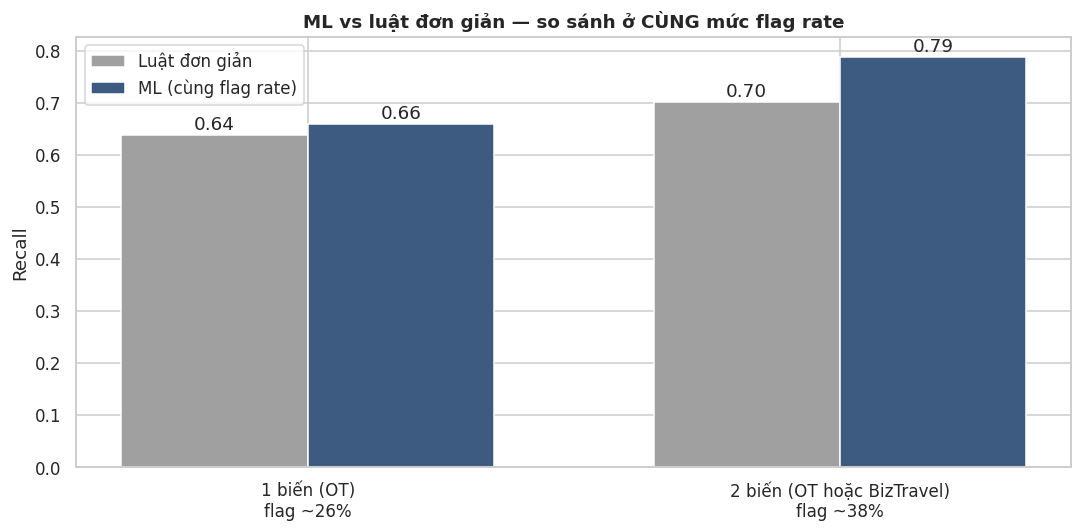

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(2)
width = 0.35
ax.bar(x - width/2, [recall_ot, recall_naive2], width, label='Luật đơn giản', color='#a0a0a0')
ax.bar(x + width/2, [recall_ml, recall_ml2], width, label='ML (cùng flag rate)', color='#3d5a80')
ax.set_xticks(x); ax.set_xticklabels(['1 biến (OT)\nflag ~26%', '2 biến (OT hoặc BizTravel)\nflag ~38%'])
ax.set_ylabel("Recall")
ax.set_title("ML vs luật đơn giản — so sánh ở CÙNG mức flag rate")
ax.legend()
for i, (v1, v2) in enumerate(zip([recall_ot, recall_naive2], [recall_ml, recall_ml2])):
    ax.text(i-width/2, v1+0.01, f"{v1:.2f}", ha='center')
    ax.text(i+width/2, v2+0.01, f"{v2:.2f}", ha='center')
plt.tight_layout()
plt.savefig("../images/20_ml_vs_naive.png", bbox_inches='tight')
plt.show()


**Câu trả lời: không nhiều, ở mức flag rate thấp.** Với luật 1 biến ("ai đang
OT thì liên hệ"), ML chỉ nhỉnh hơn +2.1 điểm % Recall, +1.3 điểm % Precision — gần như
không đáng để bỏ công build cả 1 pipeline SMOTE + so sánh 5 model + tune hyperparameter.
Khoảng cách nới rộng hơn với luật 2 biến (OT HOẶC đi công tác thường xuyên): ML v Recall
0.809 so với 0.702 của luật — chênh khoảng **+10 điểm %**.

**Giá trị thật của ML không nằm ở quyết định nhị phân "liên hệ hay không"** — một luật vài
dòng code đã làm khá tốt việc đó. Giá trị thật nằm ở 3 chỗ luật đơn giản không làm được:
1. **Xếp hạng liên tục** (risk score 0-100%) thay vì chỉ nhị phân — cho phép phân bổ nguồn
   lực HR theo capacity thực tế (notebook 05, mục 1), luật đơn giản không xếp hạng được.
2. **Kết hợp hàng chục tín hiệu yếu** cùng lúc (44 biến) thay vì chỉ 1-2 biến mạnh nhất —
   khoảng cách với ML nới rộng đúng theo hướng này khi luật thêm biến thứ 2.
3. **Giải thích được** (SHAP) — biết *vì sao* một người cụ thể rủi ro cao, luật if-else
   không tự nhiên trả lời được câu đó cho từng cá nhân.

Đây là một kết luận quan trọng cần nói thẳng với stakeholder: **đừng bán ML như một phép màu
thay thế trực giác của HR** — với dataset này, trực giác "để ý ai đang làm thêm giờ" đã đúng
phần lớn. Bán đúng giá trị: độ chi tiết, khả năng mở rộng, và khả năng giải thích.

## Tổng kết

- 4 chân dung người nghỉ việc, không phải 1 — mỗi cụm cần chiến lược giữ chân khác nhau
- Cụm "rời đi trong âm thầm" được xác nhận **độc lập lần 2** bằng clustering, khớp với
  phân tích False Negative ở notebook 05 — một phát hiện được 2 phương pháp khác nhau xác
  nhận đáng tin hơn nhiều so với chỉ 1 phân tích
- ML chỉ hơn luật đơn giản 1 biến một chút — giá trị thật nằm ở xếp hạng liên tục, kết hợp
  nhiều tín hiệu yếu, và khả năng giải thích, không phải ở việc "thông minh hơn" một cách
  chung chung
